# Customer Churn Prediction and Analysis

## Project Objective
The objective of this project is to analyze customer behavior, identify the key factors contributing to customer churn, and build a machine learning model capable of predicting whether a customer is likely to leave the company.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab

In [1]:
# load dataset
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/datasets/Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [47]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Exploratory data analysis(EDA)

The goal of EDA is to find whay are customers leaving.

*** CUSTOMER CHURN DISTRIBUTION ***

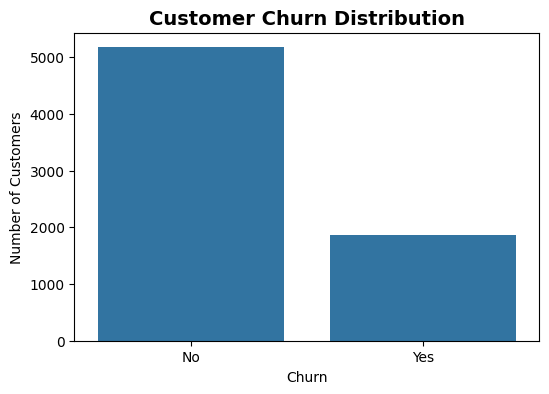

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df)

plt.title(
    "Customer Churn Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

***Insight:***

 The customer churn distribution shows that most customers remain with the company. However, approximately 26.5% of customers have churned, representing a significant loss of customers and potential revenue. This suggests that improving customer retention should be a key business priority.

***Business Recommendation:***

 The company should implement proactive retention strategies such as loyalty programs, personalized offers, and improved customer service. Further analysis should focus on identifying the factors associated with churn so that at-risk customers can be targeted before they leave.

In [12]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


***CONTRACT TYPE VS CHURN***

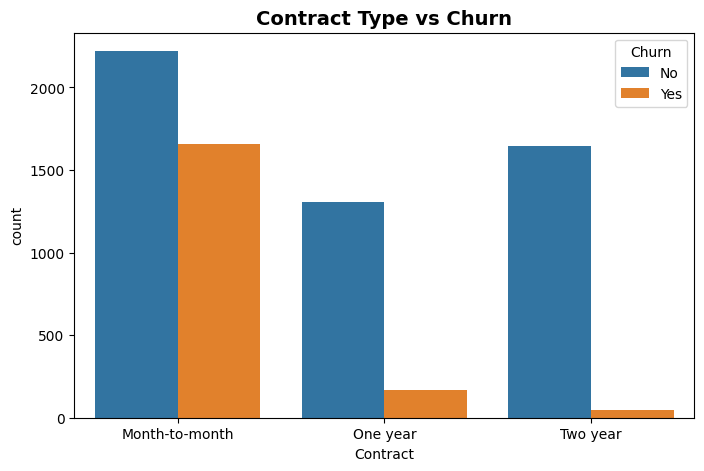

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title(
    "Contract Type vs Churn",
    fontsize=14,
    fontweight="bold"
)

plt.show()

***INSIGHTS***

The analysis reveals that customers with month-to-month contracts have the highest churn rate, while customers subscribed to one-year and two-year contracts are far less likely to leave. This suggests that contract duration plays a significant role in customer retention.

***BUSINESS RECOMMENDATION***

To improve retention, the company should promote long-term contracts through discounted pricing, loyalty incentives, and exclusive service benefits. Encouraging customers to commit to longer contract periods can help reduce churn and increase customer lifetime value.



***TENURE VS CHURN***

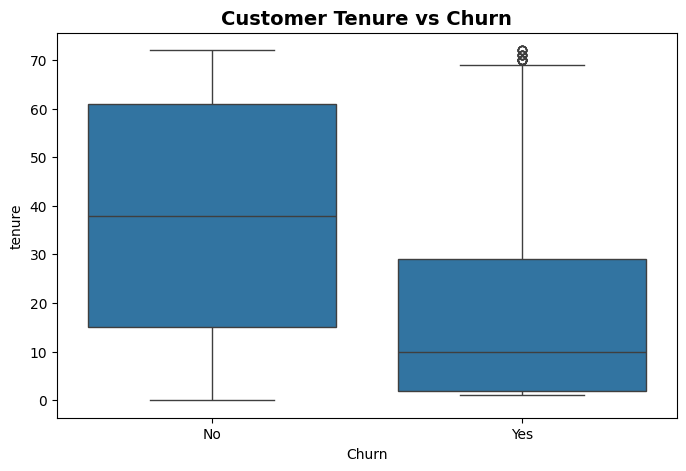

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title(
    "Customer Tenure vs Churn",
    fontsize=14,
    fontweight="bold"
)

plt.show()

***Insight:***

 The box plot shows a significant difference in tenure between churned and retained customers. Customers who churn tend to have much shorter tenures, while retained customers generally remain with the company for several years. This suggests that the risk of churn is highest during the early stages of the customer lifecycle.

***Business Recommendation:***

 The company should focus retention efforts on newly acquired customers by improving onboarding, providing personalized support, and offering early loyalty incentives. Increasing engagement during the first year of service may help reduce churn and improve long-term customer retention.

***MONTHLY CHARGES VS CHURN***

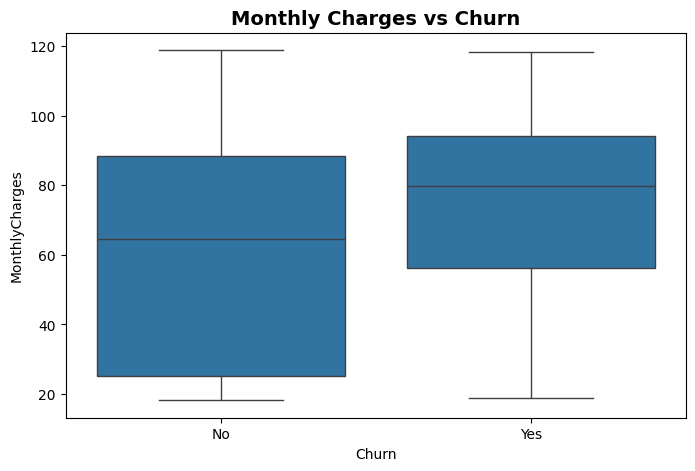

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title(
    "Monthly Charges vs Churn",
    fontsize=14,
    fontweight="bold"
)

plt.show()

***Insight:***

 Customers who churn tend to have higher monthly charges compared to customers who remain with the company. The median monthly charge for churned customers is noticeably higher, suggesting that pricing may be an important factor influencing customer retention.

***Business Recommendation:***

 The company should review pricing strategies for high-cost plans and consider offering discounts, bundled services, or loyalty rewards to customers with higher monthly charges. Providing additional value to these customers may help reduce churn and improve customer satisfaction.

***INTERNET SERVICE VS CHURN***


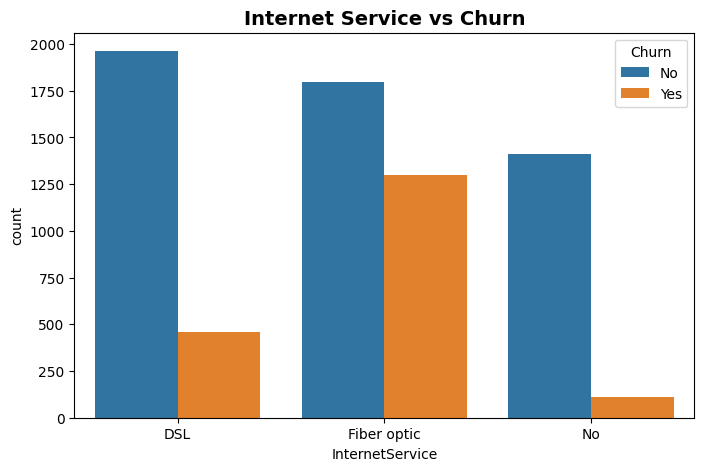

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.title(
    "Internet Service vs Churn",
    fontsize=14,
    fontweight="bold"
)

plt.show()

***Insight:***

 The analysis shows that customers using Fiber optic internet services experience significantly higher churn than customers using DSL or those without internet services. Despite having a large customer base, the Fiber optic segment contributes a disproportionately high number of churned customers, indicating potential issues related to pricing, service quality, or customer expectations.



***Business Recommendation:***

 The company should investigate the Fiber optic customer segment to identify the root causes of churn. Conducting customer satisfaction surveys, improving service reliability, and offering targeted retention incentives for Fiber optic users may help reduce customer attrition and improve retention rates.

***PAYMENT METHOD VS CHURN***


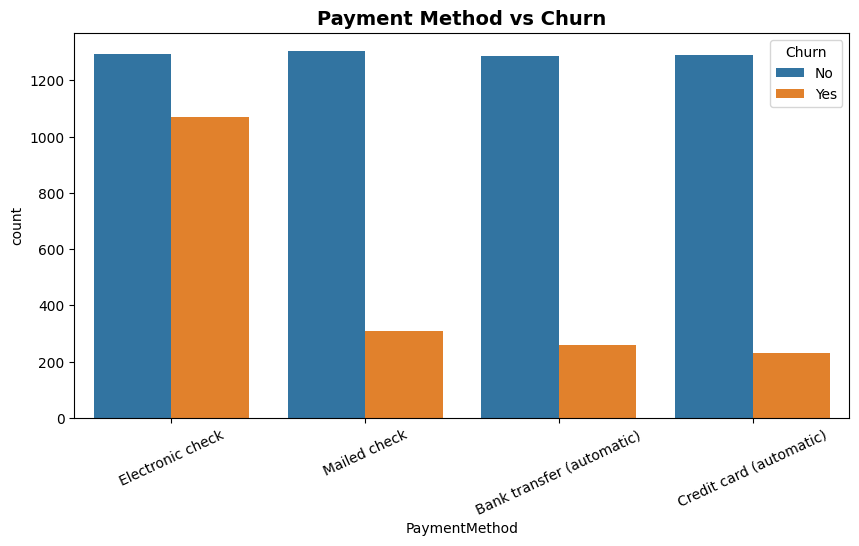

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.xticks(rotation=25)

plt.title(
    "Payment Method vs Churn",
    fontsize=14,
    fontweight="bold"
)

plt.show()

***Insight:***

 Customers who use electronic checks exhibit the highest churn levels compared to all other payment methods. In contrast, customers using automatic payment methods such as bank transfers and credit cards show substantially lower churn, suggesting that payment method is strongly associated with customer retention.

***Business Recommendation:***

 The company should encourage customers to adopt automatic payment methods by offering incentives such as discounts, cashback rewards, or loyalty benefits. Increasing the use of automated payments may improve customer retention and reduce churn.

***TECH SUPPORT VS CHURN***

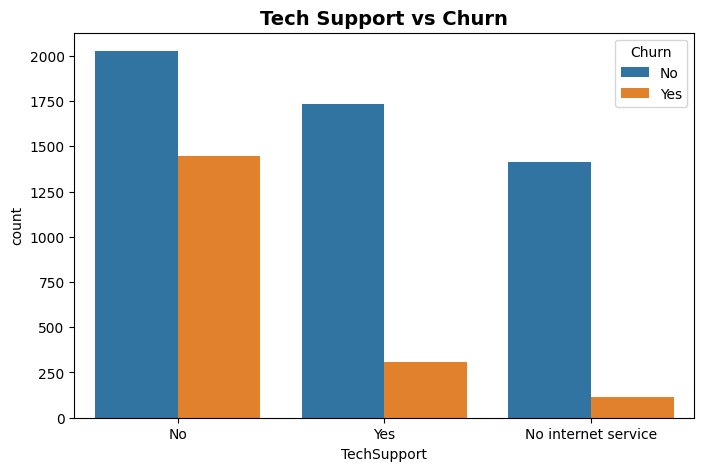

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="TechSupport",
    hue="Churn",
    data=df
)

plt.title(
    "Tech Support vs Churn",
    fontsize=14,
    fontweight="bold"
)

plt.show()

***Insight:***

 Customers without technical support exhibit significantly higher churn levels than customers who have access to technical support services. The substantial difference between the two groups suggests that customer support plays a critical role in retaining customers and reducing attrition.

***Business Recommendation:***

 The company should promote technical support services and encourage adoption among existing customers. Offering bundled support packages, improving service quality, and providing proactive assistance may help reduce churn and improve customer satisfaction.

***EDA SUMMARY***

                     KEY FINDINGS:

1. Month-to-month contract customers have the highest churn rates.
2. Customers with shorter tenure are more likely to leave.
3. Higher monthly charges are associated with increased churn.
4. Fiber optic customers experience significantly higher churn.
5. Customers using electronic checks show the highest churn among payment      methods.
6. Customers without technical support are substantially more likely to churn.

                 OVERALL RECOMMENDATION:
                 
 The company should focus retention efforts on new customers, month-to-month subscribers, Fiber optic users, and customers without technical support. Incentives for long-term contracts, improved customer support, and targeted retention campaigns could significantly reduce customer churn.

In [19]:
# feature engineering / encoding:
   # removing  customer id, it doesn't help predict churn
df = df.drop("customerID", axis=1)

In [21]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
# converting target variable (churn) from (yes and no ) to (0 and 1)
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [23]:
df["Churn"].head()

,Churn
0,0
1,0
2,1
3,0
4,1


In [25]:
# convert all text columns
df = pd.get_dummies(
    df,
    drop_first=True
)

In [35]:
# converting boolean columns to intigers
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [36]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [37]:
df.shape


(7043, 31)

In [48]:
# separating feeatures and target
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [49]:
# split data and train model
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [50]:
print(X_train.shape)
print(X_test.shape)

(5634, 30)
(1409, 30)


In [51]:
# train logistic regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=5000
)
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [53]:
y_pred = model.predict(X_test)

In [57]:
# model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8218594748048261
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



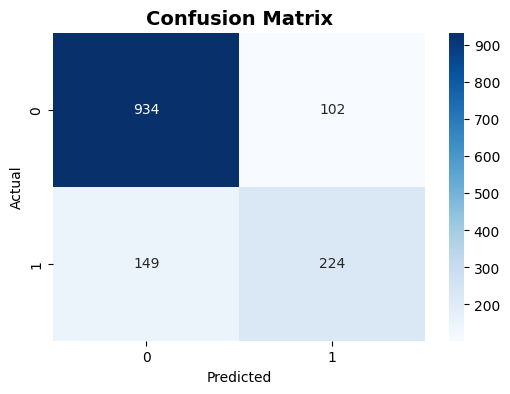

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Confusion Matrix",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [58]:
# feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

importance.head(10)

,Feature,Coefficient
10,InternetService_Fiber optic,0.647129
26,PaperlessBilling_Yes,0.335218
28,PaymentMethod_Electronic check,0.328176
8,MultipleLines_No phone service,0.270478
23,StreamingMovies_Yes,0.229341
9,MultipleLines_Yes,0.220839
0,SeniorCitizen,0.159765
21,StreamingTV_Yes,0.126151
5,Partner_Yes,0.055084
2,MonthlyCharges,0.002885


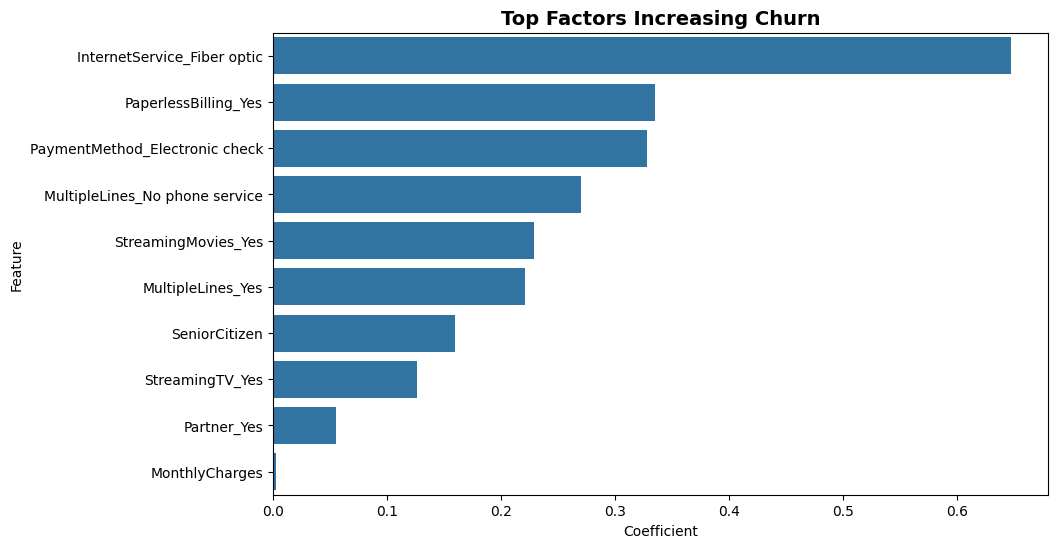

In [59]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=top10
)

plt.title(
    'Top Factors Increasing Churn',
    fontsize=14,
    fontweight='bold'
)

plt.show()

In [60]:
importance.sort_values(
    by='Coefficient',
    ascending=True
).head(10)

,Feature,Coefficient
25,Contract_Two year,-1.409641
24,Contract_One year,-0.639636
13,OnlineSecurity_Yes,-0.469651
7,PhoneService_Yes,-0.442321
19,TechSupport_Yes,-0.390872
15,OnlineBackup_Yes,-0.211242
6,Dependents_Yes,-0.159719
14,OnlineBackup_No internet service,-0.099260
22,StreamingMovies_No internet service,-0.099260
18,TechSupport_No internet service,-0.099260


##FEATURE IMPORTANCE ANALYSIS

***Insight:***

 The model identified long-term contracts as the strongest factors reducing customer churn. Customers subscribed to one-year and two-year contracts were significantly less likely to leave the company. Additionally, customers with online security and technical support services demonstrated higher retention rates, suggesting that value-added services contribute positively to customer loyalty.

***Business Recommendation:***

 The company should encourage customers to migrate from month-to-month plans to long-term contracts through targeted discounts and loyalty rewards. Expanding the adoption of technical support and online security services may further improve customer retention and reduce churn rates.


  ## MACHINE LEARNING RESULTS

  ***Model Performance***


                              Insight:

 The Logistic Regression model achieved an accuracy of 82.19%, indicating strong overall performance in predicting customer churn. The model correctly classified the majority of customers and demonstrated good predictive capability for a baseline machine learning model.


***Churn Prediction Performance***

                              Insight:

 The model achieved a recall score of 60% for churned customers, meaning it successfully identified a majority of customers who eventually left the company. However, some churn cases were missed, suggesting opportunities for further model improvement.

***Business Recommendation***

                          Recommendation:

 The model can be used to identify customers at risk of churn and support proactive retention efforts. Customers flagged as high risk can be targeted with loyalty programs, personalized offers, and enhanced customer support to reduce customer attrition.




                             Key Findings:

Month-to-month customers have the highest churn rates.
New customers are more likely to churn than long-term customers.
Higher monthly charges are associated with increased churn.
Fiber optic users exhibit higher churn levels.
Electronic check users have the highest churn among payment methods.
Customers without technical support are significantly more likely to leave.

                              Model Result:

Logistic Regression Accuracy: 82.19%
The model successfully predicts customer churn and can support customer retention strategies.

                             Business Impact:
                             
 The analysis identified several factors strongly associated with customer churn. By focusing on contract upgrades, customer onboarding, pricing strategies, payment methods, and technical support services, the company can improve customer retention and reduce revenue loss due to churn.
